# Unique Solution of Schochastic Fixed-Point Equation

This notebook is to check conjectures in proving that the SFPE
$$X \stackrel{d}{=} I(U^{\alpha}X^{(1)} + (1-U)^{\alpha}X^{(2)}) + J\max(U^{\alpha}X^{(1)}, (1-U)^{\alpha}X^{(2)})$$

has a unique solution $(\alpha^*, X_{\alpha^*})$ such that $\mathbb{E}[X_{\alpha^*}] = 1$.

The classical contraction method does not work: because of the sum, $W_p$ does not work; because of the max, $\zeta_p$ does not work.

In [24]:
# Helper cell: set up imports and paths for modules

import sys

modules_path = "/home/stages/chau/projects/internship-bezout/src/modules"
if modules_path not in sys.path:
    sys.path.insert(0, modules_path)

import importlib

import operators
import monte_carlo

importlib.reload(operators)
importlib.reload(monte_carlo)

from operators import S, T
from monte_carlo import wasserstein, plot_distribution

import numpy as np
import matplotlib.pyplot as plt

In [ ]:
u=0.6
v=0.3
alpha=0.5

X = np.ones(1000000)

for _ in range(20):
  X = T(X, u, v, alpha)
  print(f"Iteration {_+1}/20: mean: {X.mean():.6f}, std: {X.std():.6f}")

Iteration 1/20: mean: 1.058688, std: 0.418909
Iteration 2/20: mean: 1.139131, std: 0.560270
Iteration 3/20: mean: 1.235582, std: 0.667827
Iteration 4/20: mean: 1.343416, std: 0.765380
Iteration 5/20: mean: 1.463464, std: 0.859987
Iteration 6/20: mean: 1.596348, std: 0.954812
Iteration 7/20: mean: 1.741793, std: 1.054634
Iteration 8/20: mean: 1.903193, std: 1.160731
Iteration 9/20: mean: 2.079530, std: 1.272147
Iteration 10/20: mean: 2.272627, std: 1.394389
Iteration 11/20: mean: 2.483756, std: 1.525486
Iteration 12/20: mean: 2.714484, std: 1.668216
Iteration 13/20: mean: 2.966922, std: 1.825774
Iteration 14/20: mean: 3.243638, std: 1.999045
Iteration 15/20: mean: 3.545817, std: 2.185250
Iteration 16/20: mean: 3.873757, std: 2.388185
Iteration 17/20: mean: 4.232134, std: 2.609926
Iteration 18/20: mean: 4.624769, std: 2.853837
Iteration 19/20: mean: 5.054299, std: 3.119644
Iteration 20/20: mean: 5.525679, std: 3.410174


Iteration 1/20: W2(X_1, Y_1) = 0.189701


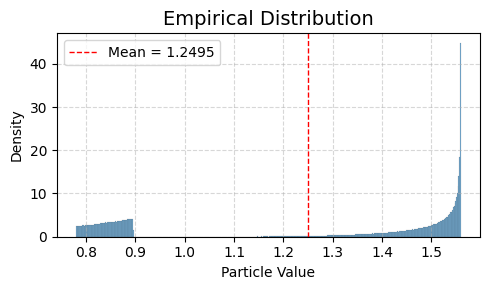

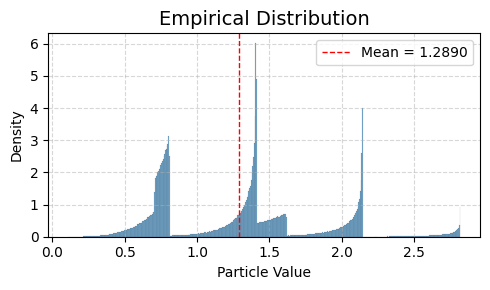

Iteration 2/20: W2(X_2, Y_2) = 0.087199


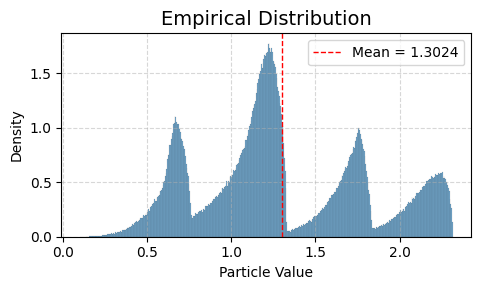

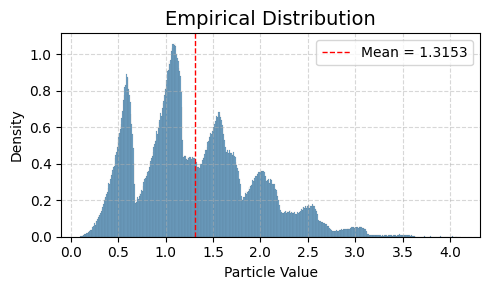

Iteration 3/20: W2(X_3, Y_3) = 0.043561


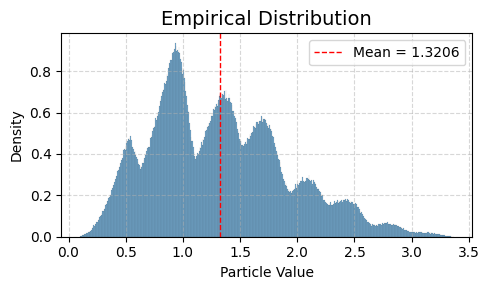

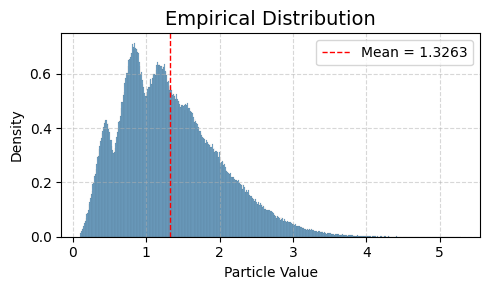

Iteration 4/20: W2(X_4, Y_4) = 0.026486


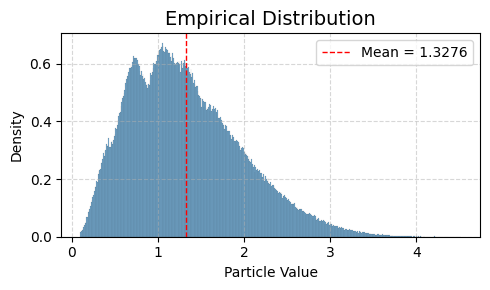

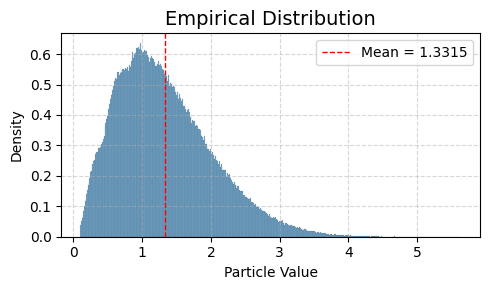

Iteration 5/20: W2(X_5, Y_5) = 0.015026


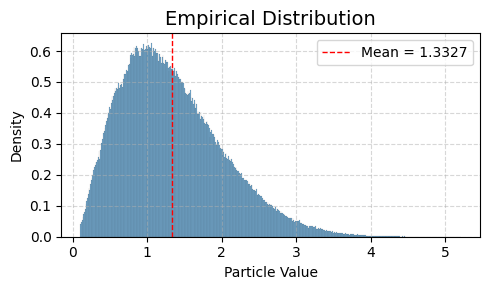

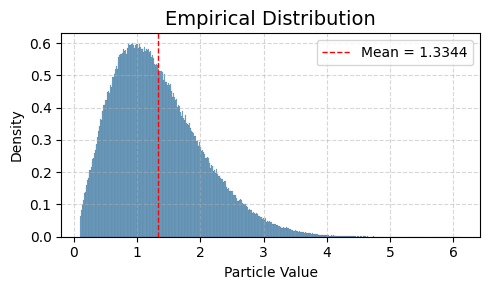

Iteration 6/20: W2(X_6, Y_6) = 0.010462


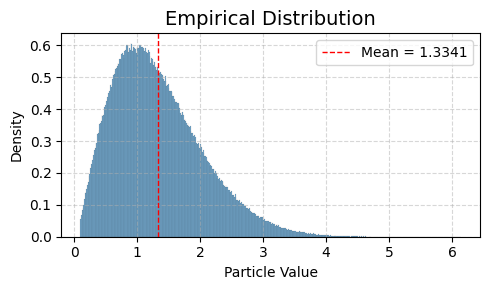

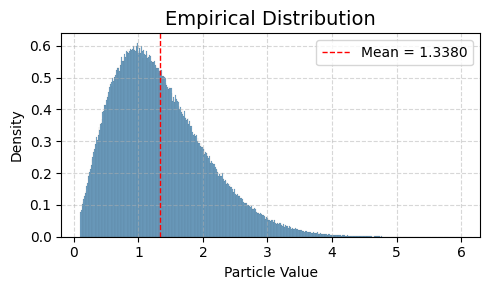

Iteration 7/20: W2(X_7, Y_7) = 0.007073


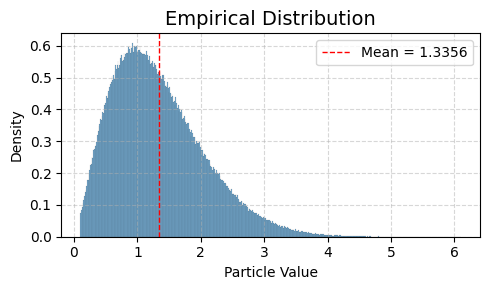

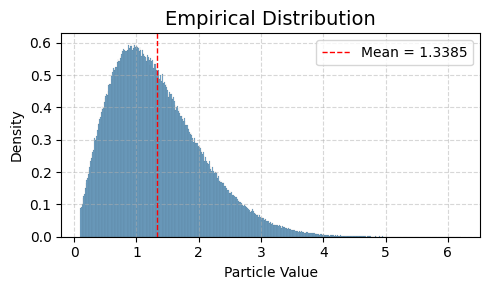

Iteration 8/20: W2(X_8, Y_8) = 0.005191


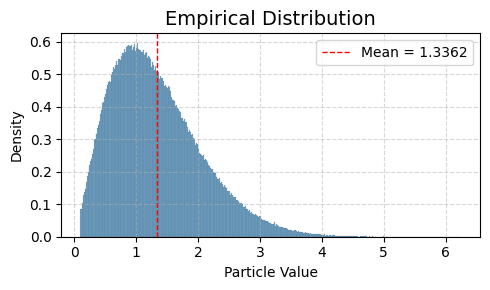

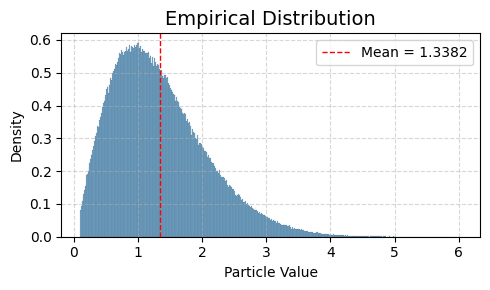

Iteration 9/20: W2(X_9, Y_9) = 0.004246


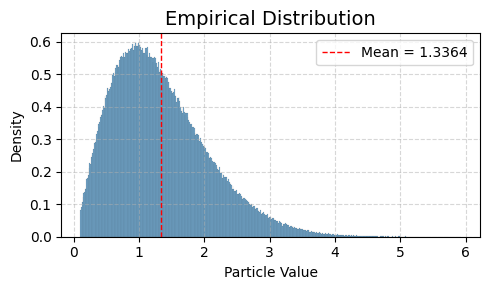

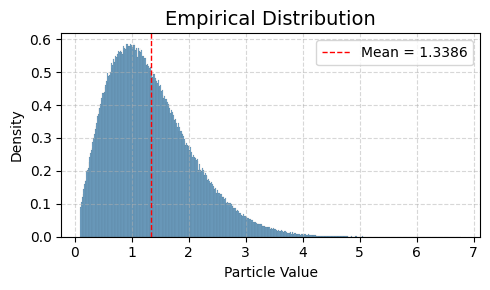

Iteration 10/20: W2(X_10, Y_10) = 0.003165


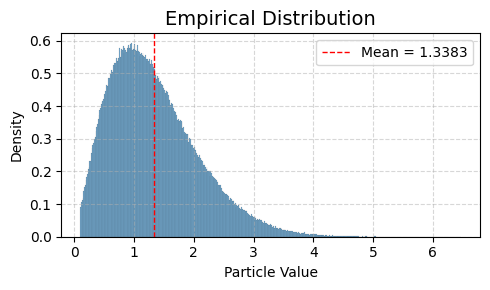

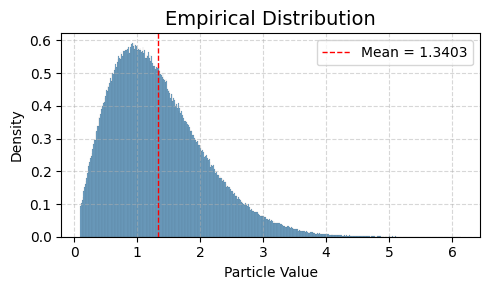

Iteration 11/20: W2(X_11, Y_11) = 0.002494


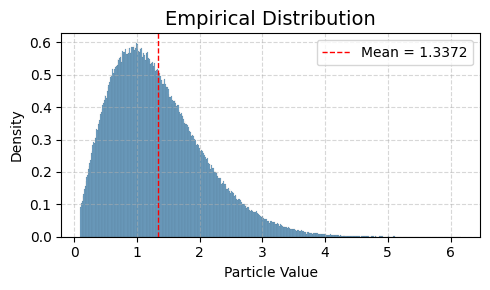

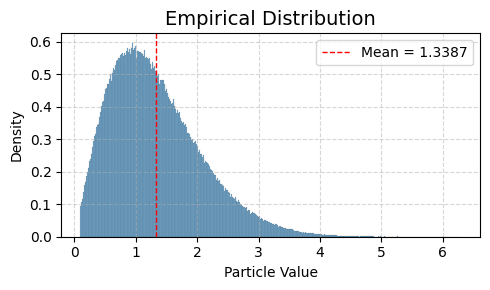

Iteration 12/20: W2(X_12, Y_12) = 0.002038


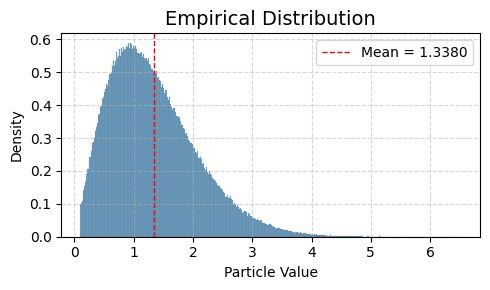

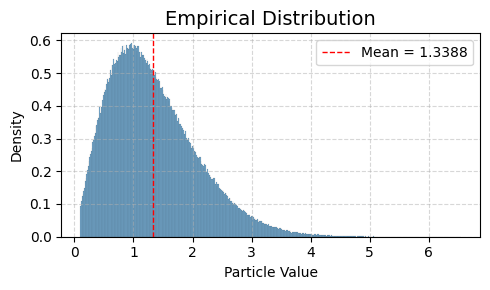

Iteration 13/20: W2(X_13, Y_13) = 0.001575


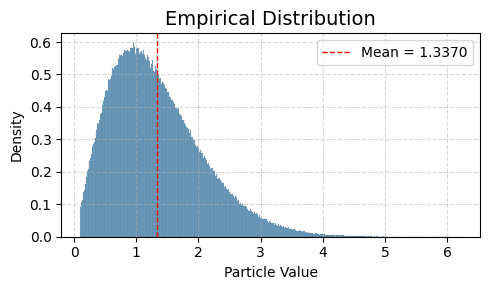

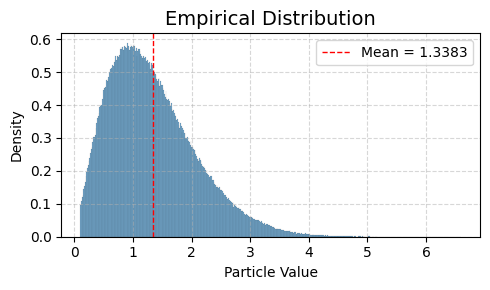

Iteration 14/20: W2(X_14, Y_14) = 0.000660


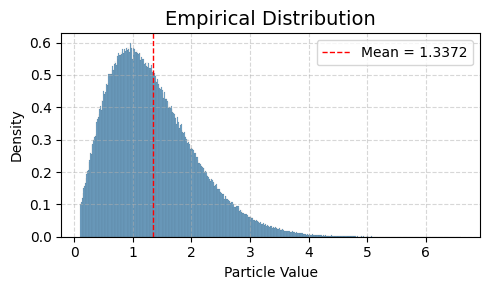

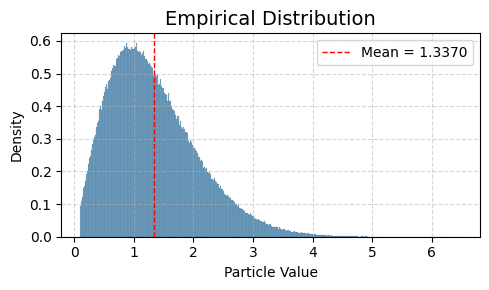

Iteration 15/20: W2(X_15, Y_15) = 0.000677


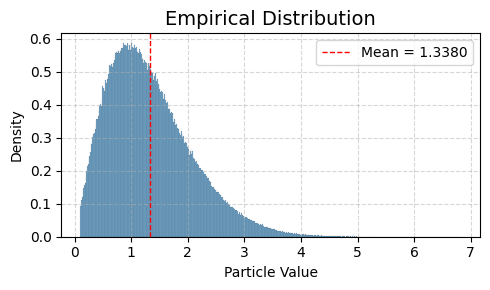

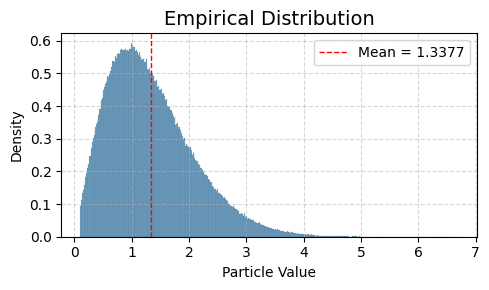

Iteration 16/20: W2(X_16, Y_16) = 0.000769


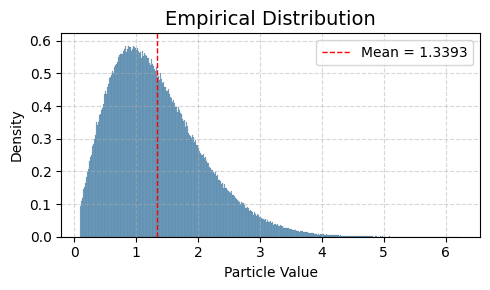

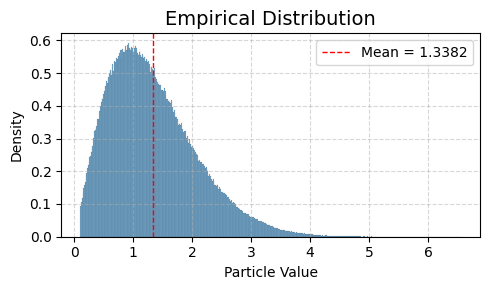

Iteration 17/20: W2(X_17, Y_17) = 0.001162


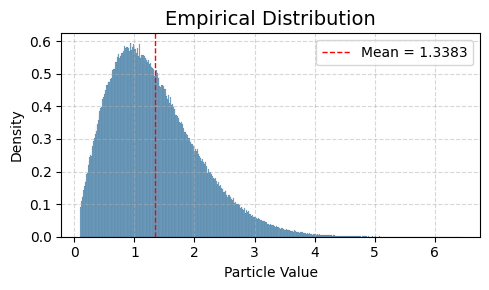

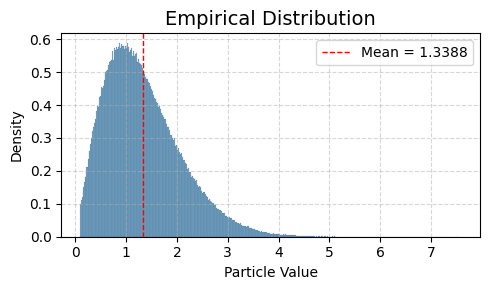

Iteration 18/20: W2(X_18, Y_18) = 0.001696


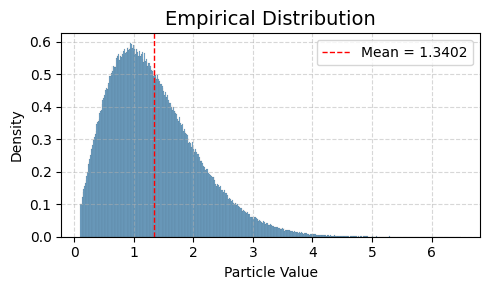

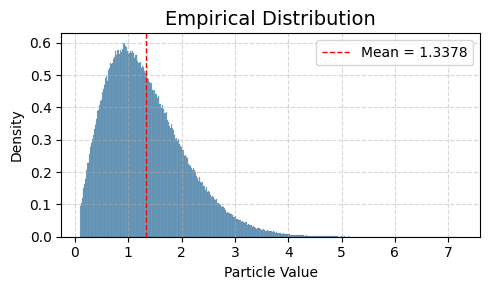

Iteration 19/20: W2(X_19, Y_19) = 0.002877


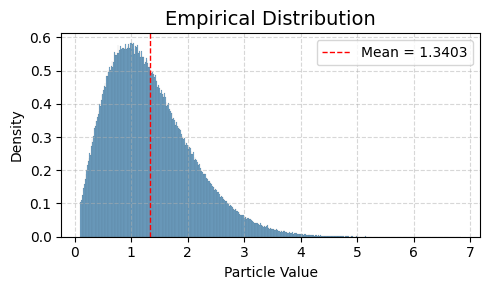

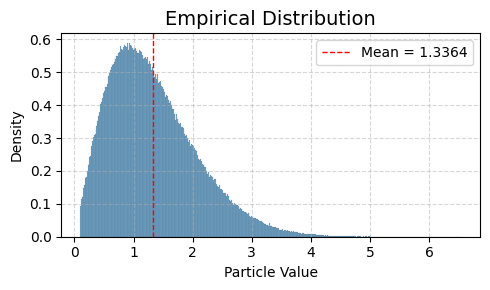

Iteration 20/20: W2(X_20, Y_20) = 0.001398


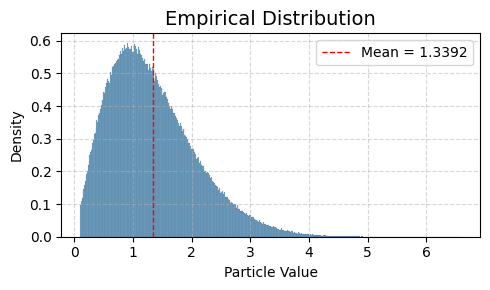

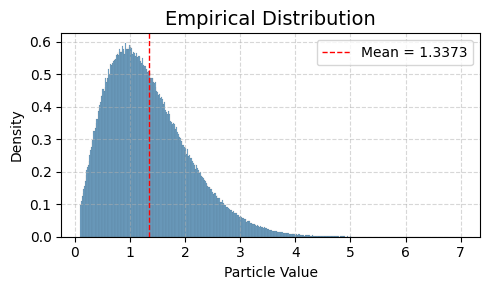

In [28]:

u=0.5
v=0.3
alpha=0.2
num_particles = 1000000

X_init = np.ones(num_particles)
X = X_init
X_next = X_init

Y_init = np.random.binomial(1, 2-1/(u+v), size=num_particles) + np.random.binomial(1, v, size=num_particles)
Y = Y_init
Y_next = Y_init

for i in range(20):
  X = X_next
  X_next = S(X, u, v, alpha)

  Y = Y_next
  Y_next = S(Y, u, v, alpha)

  print(f"Iteration {i+1}/20: W2(X_{i+1}, Y_{i+1}) = {wasserstein(X_next, Y_next):.6f}")
  

  plot_distribution(X_next[X_next > 0.1], bins=500, show_bins=True, show_kde=False, fig_size=(5, 3))
  plot_distribution(Y_next[Y_next > 0.1], bins=500, show_bins=True, show_kde=False, fig_size=(5, 3))


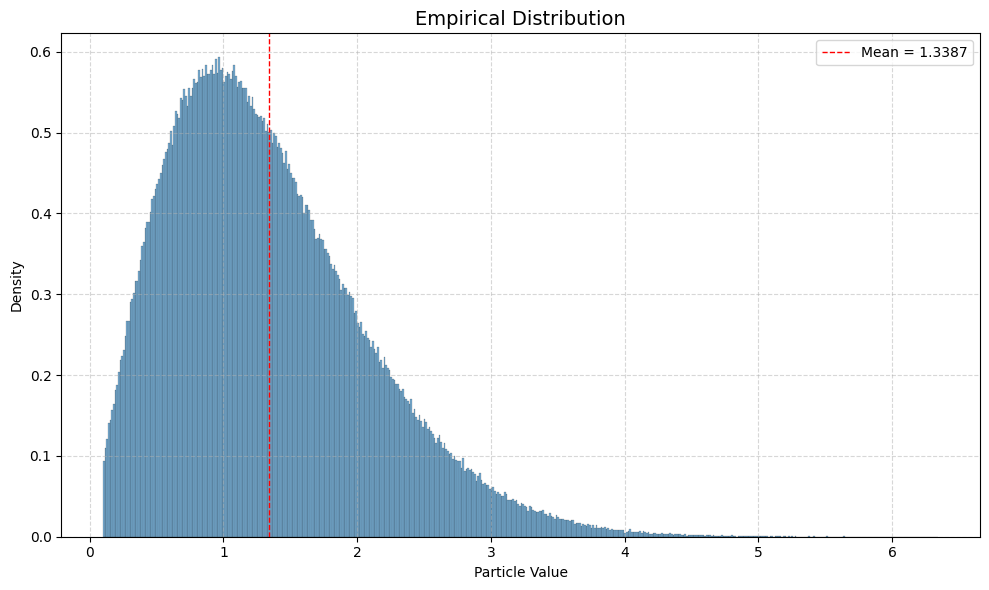

In [14]:
plot_distribution(X_next[X_next > 0.1], bins=500, show_bins=True, show_kde=False)

#### Check convergence to an $\alpha$ and unique limit distribution

##### Bisection

In [7]:
def cummulative_mean(alpha, u, v, X, burn_in=15, num_iters=40):
    
    multipliers = []
    
    for i in range(burn_in + num_iters):
        Y = apply_T(X, u, v, alpha)
        step_mean = np.mean(Y)

        X = Y / step_mean
                
        # Record the multiplier (ignoring the burn-in period)
        if i >= burn_in:
            multipliers.append(step_mean)
            
    return np.mean(multipliers), X

def find_alpha(u, v, X_init, lower, upper, tolerance=1e-10, max_steps=15):
    """
    Uses bisection search to find the root of cummulative_mean(alpha) = 1.
    """
    print(f"Searching for alpha* for u={u}, v={v}")
    print(f"{'Step':<5} | {'Alpha Estimate':<15} | {'Cumulative Mean':<15}")
    print("-" * 40)
    
    for step in range(max_steps):
        mid_alpha = (lower + upper) / 2.0
        
        # Estimate the growth rate for this alpha
        current_mean, X = cummulative_mean(mid_alpha, u, v, X_init)
        
        print(f"{step+1:<5} | {mid_alpha:<15.5f} | {current_mean:<15.5f}")
        
        # Check for convergence
        if abs(current_mean - 1.0) < tolerance:
            print("-" * 40)
            print(f"Converged! alpha* = {mid_alpha:.5f}")
            return mid_alpha, X
            
        # If current_mean > 1, increase alpha.
        if current_mean > 1.0:
            lower = mid_alpha
        else:
            upper = mid_alpha
            
    print("-" * 40)
    print(f"Reached max steps. Best estimate for alpha* ≈ {mid_alpha:.5f}")
    return mid_alpha, X


##### Robbins-Monro

In [ ]:
def find_alpha_rm(u, v, num_particles=100000, num_iters=20000, initial_alpha=0.4, lrs=None):
    """
    Use Robbins-Monro stochastic approximation.
    """

    if lrs is None:
        # Learning rate schedule parameters
        # c_n = c0 / (n ** gamma)
        c0 = 0.2
        gamma = 0.65 
        lrs = [c0 / (n ** gamma) for n in range(1, num_iters + 1)]
    
    if len(lrs) != num_iters:
        raise ValueError("Length of learning rates must match num_iters.")

    # Initialize the population as a Dirac delta at 1
    X = np.ones(num_particles)
    
    alpha = initial_alpha
    alpha_history = []
    mean_history = []
    
    print(f"Starting Robbins-Monro for u={u}, v={v}")
    print(f"{'Iter':<6} | {'Current Alpha':<15} | {'Step Mean':<15} | {'P(X=0)' :<15}")
    print("-" * 60)
    
    for n in range(1, num_iters + 1):
        Y = apply_T(X, u, v, alpha)
        step_mean = np.mean(Y)
        
        X = Y / step_mean
        
        # If mean > 1, increase alpha, otherwise decrease it.
        alpha = alpha + lrs[n - 1] * (step_mean - 1.0)
        
        # Ensure alpha remains strictly positive
        alpha = max(0.01, alpha)
        
        alpha_history.append(alpha)
        mean_history.append(step_mean)
        
        if n % 2000 == 0:
            print(f"{n:<6d} | {alpha:<15.5f} | {step_mean:<15.5f} | {1-np.count_nonzero(X)/len(X):<15.5f} ")

    # Polyak-Ruppert Averaging: Average the alpha values from the second half of the run
    burn_in = num_iters // 2
    alpha_star_estimate = np.mean(alpha_history[burn_in:])
    
    print("-" * 45)
    print(f"Final alpha: {alpha_history[-1]:.5f}, Polyak-Ruppert Estimate: {alpha_star_estimate:.5f}")
    
    return alpha_star_estimate, X, alpha_history, mean_history

Starting Robbins-Monro for u=0.5, v=0.3
Iter   | Current Alpha   | Step Mean       | P(X=0)         
------------------------------------------------------------
2000   | 0.47526         | 1.00010         | 0.25019         
4000   | 0.47651         | 1.00045         | 0.25007         
6000   | 0.47674         | 1.00113         | 0.24996         
8000   | 0.47688         | 1.00177         | 0.25010         
10000  | 0.47690         | 1.00347         | 0.24992         
12000  | 0.47693         | 0.99809         | 0.25047         
14000  | 0.47694         | 1.00049         | 0.24988         
16000  | 0.47695         | 0.99819         | 0.25050         
18000  | 0.47696         | 1.00112         | 0.24881         
20000  | 0.47695         | 0.99928         | 0.24874         
---------------------------------------------
Final alpha*: 0.47694240328599447
W1 distance between final X and T_alpha(X): 0.002113


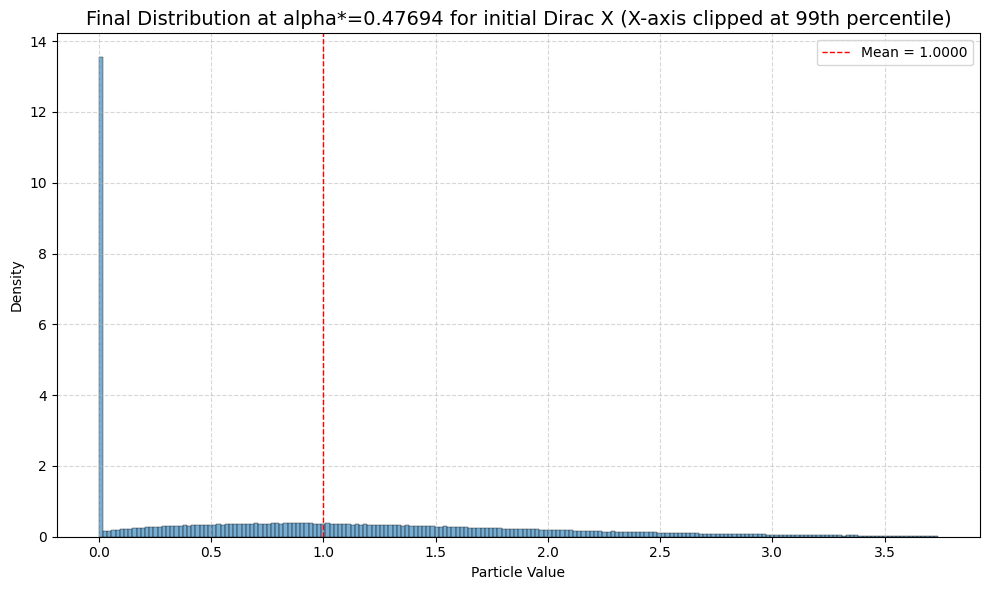

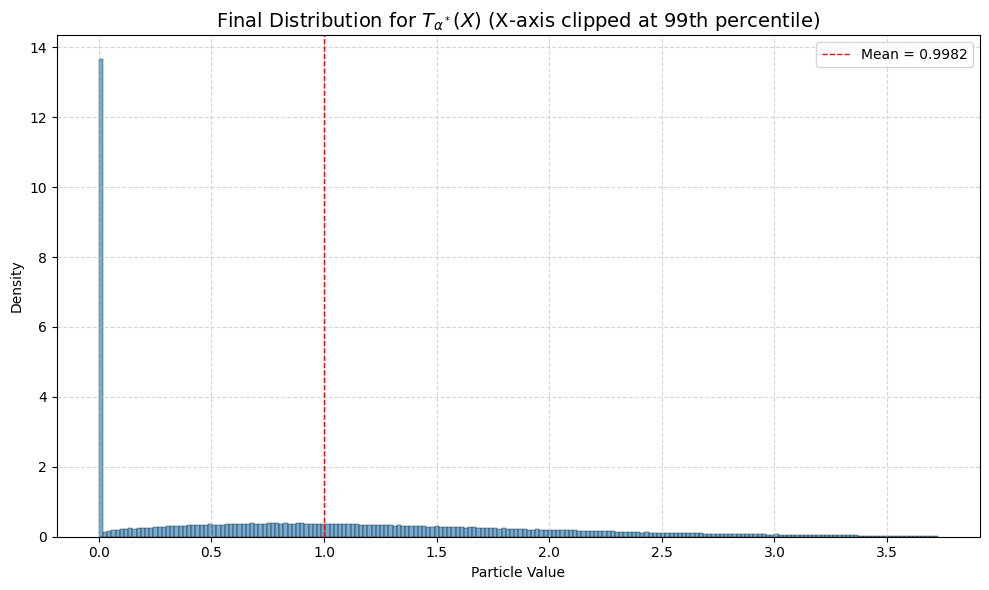

In [ ]:
u = 0.5
v = 0.3
N=1000000
num_iters=20000
lrs = [0.2 / (n ** 0.65) for n in range(1, num_iters + 1)]


alpha, X_final, a_hist, m_hist = find_alpha_rm(u, v, 400000, 20000, initial_alpha=0.3, lrs=lrs)

T_X_final = apply_T(X_final, u, v, alpha)
print(f"W1 distance between final X and T_alpha(X): {wasserstein(X_final, T_X_final):.6f}")

plot_distribution(X_final, title=f"Final Distribution at alpha*={alpha:.5f} for initial Dirac X", clip_percentile=99, show_bins=True, show_kde=False, bins=200)
plot_distribution(T_X_final, title=f"Final Distribution for $T_{{\\alpha^*}}(X)$", clip_percentile=99, show_bins=True, show_kde=False, bins=200)

#### Check if that $\alpha$ may be the true power.

##### Compute distribution of $Y_n$

$$Y_{n+1} = I\left(Y_{U_n}^{(1)} + Y_{n-1-U_n}^{(2)} + 1\right) + J\max\left(Y_{U_n}^{(1)}, Y_{n-1-U_n}^{(2)}\right), \quad Y_0=Y_2=1.$$

Given that the subscripts are for independent copies. The variables $I$ and $J$ are Bernoulli with expectation $u$ and $v$ respectively such that $I+J\le 1$ and $u+v\le 1$, and they are inpependent of all $Y^{(j)}_i$.

In [ ]:
def compute_Yn(max_N, u, v):

    pmfs = [np.array([1.0]), np.array([1.0])]
    cdfs = [np.array([1.0]), np.array([1.0])]
    
    termination_prob = 1.0 - u - v

    for n_target in range(2, max_N + 1):
        if n_target % 10 == 0:
            print(f"Computing up to n={n_target}...")
            
        current_pmf = np.zeros(n_target)

        n = n_target - 1
        
        # U_n is uniform over {0, ..., n-1}
        # Evaluate up to floor(n/2) and double the weights for symmetry
        for k in range((n + 1) // 2):
            j = n - 1 - k
            weight = 2.0 if k != j else 1.0
            
            # Concatenation: convolution
            conv_pmf = np.convolve(pmfs[k], pmfs[j])
            concat_pmf = np.zeros(len(conv_pmf) + 1)

            # Shift by 1 for the "+ 1"
            concat_pmf[1:] = conv_pmf  
            
            length_c = min(len(concat_pmf), n)
            current_pmf[:length_c] += weight * u * concat_pmf[:length_c]
            
            # Alternation
            len_k = len(cdfs[k])
            len_j = len(cdfs[j])
            max_len = max(len_k, len_j)
            
            cdf_k_ext = np.ones(max_len)
            cdf_k_ext[:len_k] = cdfs[k]
            
            cdf_j_ext = np.ones(max_len)
            cdf_j_ext[:len_j] = cdfs[j]
            
            cdf_max = cdf_k_ext * cdf_j_ext
            
            pmf_max = np.zeros(max_len)
            pmf_max[0] = cdf_max[0]
            pmf_max[1:] = cdf_max[1:] - cdf_max[:-1]
            
            length_m = min(len(pmf_max), n)
            current_pmf[:length_m] += weight * v * pmf_max[:length_m]

        # Average over the uniform choice of U_n
        current_pmf /= n
        
        # Termination
        current_pmf[0] += termination_prob
        
        # Correct floating-point inaccuracies
        current_pmf = np.maximum(current_pmf, 0)
        current_pmf /= np.sum(current_pmf)
        
        pmfs.append(current_pmf)
        cdfs.append(np.cumsum(current_pmf))
    
    expectations = [np.sum(pmf * np.arange(len(pmf))) for pmf in pmfs]
        
    return pmfs, cdfs, expectations

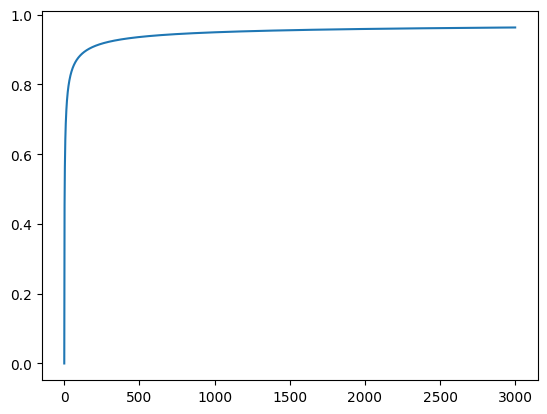

In [63]:
plt.plot(expectations[1:]/np.arange(1, len(expectations))**alpha_star)

#### Check if $T_{\alpha^*}$ has a unique fixed point

In [10]:
np.all(X_init == 1)

np.True_

#### Check if $S_\alpha = \dfrac{T_\alpha}{\mathbb{E}[T_\alpha]}$ has a fixed point

In [ ]:
Y_init,_,_ = generator.generate_uniform_shape()
plot_distribution(Y_init, title="Initial Uniform Shape", clip_percentile=99)

Y = Y_init

for _ in range(20):
    Y = apply_S(Y, u, v, alpha)

plot_distribution(Y, title=f"Final Distribution at alpha={alpha:.5f} for uniform Y", clip_percentile=99)

#### Check if $S_\alpha$ is a contraction in the $W_1$ metric.

In [ ]:
u=0.5
v=0.3
alpha=0.4

generator = MeanOneGenerator(size=1000000)
X,_,_ = generator.generate_uniform_shape()
Y,_,_ = generator.generate_custom_shape("lognorm")

plot_distribution(X, title="Initial Uniform Shape", clip_percentile=99)
plot_distribution(Y, title="Initial Lognorm Shape", clip_percentile=99)

print(f"Wp-Contraction of S_alpha (alpha={alpha}, u={u}, v={v})")
print("-" * 75)
print(f"{'Generation':<15} | {'Distance W_s(X, Y)':<25} | {'Contraction Ratio':<20}")
print("-" * 75)

for i in range(1, 30):
    
    current_dist = wasserstein(X, Y)
    
    X_next = apply_S(X, u, v, alpha)
    Y_next = apply_S(Y, u, v, alpha)
    
    next_dist = wasserstein(X_next, Y_next, p=1)
    
    ratio = next_dist / current_dist
    
    print(f"Gen {i-1:02d} -> {i:02d}  | {current_dist:<25.6f} | {ratio:<20.6f}")
    
    X, Y = X_next, Y_next

$X_n = I\left(\left(\dfrac{U_n}{n}\right)^\alpha X_{U_n} + \left(\dfrac{n-1-U_n}{n}\right)^\alpha X_{n-1-U_n} + \dfrac{1}{n^\alpha}\right) + J\max\left(\left(\dfrac{U_n}{n}\right)^\alpha X_{U_n}, \left(\dfrac{n-1-U_n}{n}\right)^\alpha X_{n-1-U_n}\right)$

Here $I,J$ are mutually exclusive Bernoulli and $U_n$ is uniform over $\{0,\ldots,n-1\}$. Let $X_0=X_1=0$. 

The paramemter $\alpha$ is chosen such that the fixed-point equation
$$X \stackrel{d}{=} I(U^\alpha X^{(1)} + (1-U)^{\alpha} X^{(2)}) + J\max(U^\alpha X^{(1)}, (1-U)^{\alpha} X^{(2)})$$

has a unique mean-1 solution $X$. Here $X^{(1)}$ and $X^{(2)}$ are iid copies of $X$ and $U$ is uniform over $[0,1]$.

#### Check if contraction method works

In [ ]:
import scipy.integrate as integrate

def compute_H(p, u, v, alpha):
    """
    Computes the contraction function H(p, alpha) for a given p.
    
    Parameters:
    p (float): The Wasserstein parameter / power.
    u (float): Probability of the sum operation (I).
    v (float): Probability of the max operation (J).
    alpha (float): The scaling exponent.
    
    Returns:
    float: The evaluated value of H(p, alpha).
    """
    # 1. Define the integrand: (x^alpha + (1-x)^alpha)^p
    def integrand(x):
        return (x**alpha + (1 - x)**alpha)**p
    
    # 2. Compute the integral from 0 to 1
    # quad returns a tuple: (value_of_integral, estimate_of_absolute_error)
    integral_value, error_estimate = integrate.quad(integrand, 0, 1, epsrel=1e-12)
    
    # 3. Add the maximum term component
    max_term = (2 * v) / (alpha * p + 1)
    
    # 4. Combine for the final result
    H_value = u * integral_value + max_term
    
    return H_value


u = 0.5
v = 0.3

lower = 0
upper = 1

alpha = 0.5
p=1

print(f"Iteration | alpha | H(p={p}, alpha)")

for _ in range(20):
    mid = (lower + upper) / 2
    H_mid = compute_H(p, u, v, mid)

    if H_mid < 1:
        upper = mid
    else:        
        lower = mid

    print(f"{_+1:9d} | {mid:.6f} | {H_mid:.6f}")

    alpha = mid



Iteration | alpha | H(p=1, alpha)
        1 | 0.500000 | 1.066667
        2 | 0.750000 | 0.914286
        3 | 0.625000 | 0.984615
        4 | 0.562500 | 1.024000
        5 | 0.593750 | 1.003922
        6 | 0.609375 | 0.994175
        7 | 0.601562 | 0.999024
        8 | 0.597656 | 1.001467
        9 | 0.599609 | 1.000244
       10 | 0.600586 | 0.999634
       11 | 0.600098 | 0.999939
       12 | 0.599854 | 1.000092
       13 | 0.599976 | 1.000015
       14 | 0.600037 | 0.999977
       15 | 0.600006 | 0.999996
       16 | 0.599991 | 1.000006
       17 | 0.599998 | 1.000001
       18 | 0.600002 | 0.999999
       19 | 0.600000 | 1.000000
       20 | 0.599999 | 1.000000


In [28]:
def apply_T(X, alpha, times=1, type:Literal["sum", "max"]="sum"):

    Y = X

    for _ in range(times):
      # Sample independent pairs
      Y1 = sample_from_empirical(Y)
      Y2 = sample_from_empirical(Y)
      
      # Sample U
      U = np.random.uniform(0, 1, size=len(Y))

      # Apply the operator T_alpha
      term1 = (U**alpha) * Y1
      term2 = ((1 - U)**alpha) * Y2

      if type == "sum":
          sum = term1 + term2
      else:
          sum = np.maximum(term1, term2)

    return sum

def apply_S(X, alpha, times=1, type:Literal["sum", "max"]="sum"):

    Y = X

    for _ in range(times):
      # Sample independent pairs
      Y1 = sample_from_empirical(Y)
      Y2 = sample_from_empirical(Y)
      
      # Sample U
      U = np.random.uniform(0, 1, size=len(Y))

      # Apply the operator S_alpha
      term1 = (U**alpha) * Y1
      term2 = ((1 - U)**alpha) * Y2

      if type == "sum":
          sum = term1 + term2
      else:
          sum = np.maximum(term1, term2)

      Y = sum - np.mean(sum) + 1

    return Y

def apply_S_for_pair(X, Y, alpha, times, type:Literal["sum", "max"]="sum"):
    for _ in range(times):
        X = apply_S(X, alpha, times=1, type=type)
        Y = apply_S(Y, alpha, times=1, type=type)

        print(f"After iteration {_+1}: W1 distance = {wasserstein(X, Y):.6f}")

    return X, Y

In [64]:
np.isfinite(X_final)

array([ True,  True,  True, ...,  True,  True,  True])

In [65]:
X_final

array([0.        , 0.61348757, 2.33516386, ..., 0.17339038, 0.2979789 ,
       0.12687958])

In [69]:
len([x for x in X_final if x == 0])/len(X_final)

0.24982

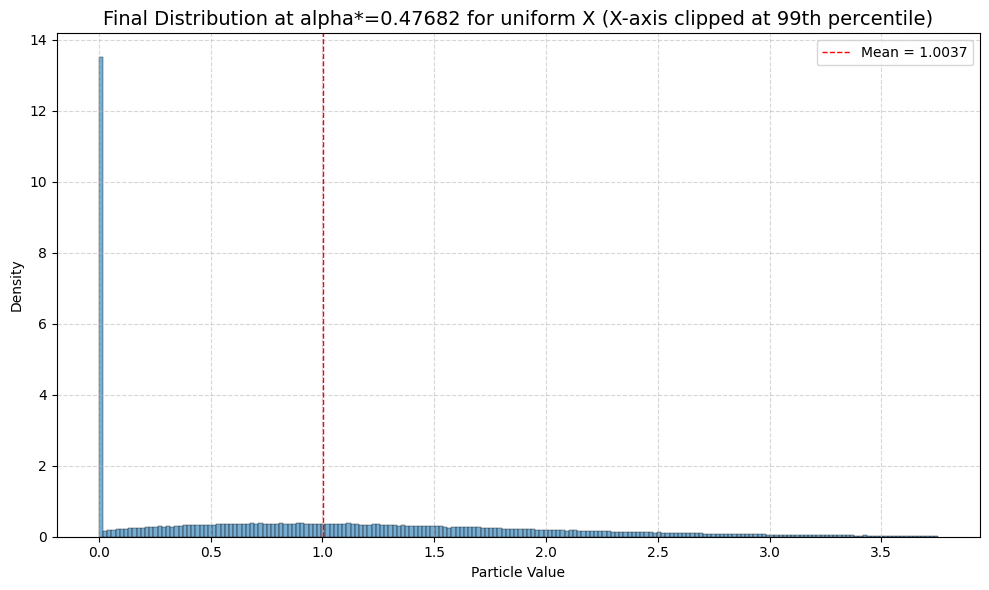

In [38]:
plot_distribution(T_X_final, title=f"Final Distribution at alpha*={alpha:.5f} for uniform X", clip_percentile=99, show_bins=True, show_kde=False, bins=200)